# **Car Price Prediction — Regression Analysis**

**Author:** Aila Nasir  
**Dataset:** UCI Automobile Dataset

## Objective
Predict automobile price using technical specifications and identify which features
most strongly influence pricing, while ensuring the model generalizes well to unseen data.

In [1]:
# Install required package for dataset access
!pip install ucimlrepo -q

## Phase 1: Data Loading and Initial Inspection

Loading the UCI Automobile dataset directly through the `ucimlrepo` package
for full reproducibility, then inspecting its structure before any cleaning.

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch dataset directly from UCI repository
automobile = fetch_ucirepo(id=10)

# Combine features and target into one dataframe
X = automobile.data.features
y = automobile.data.targets
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (205, 26)


,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,...,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses,symboling
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN,3
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN,3
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,...,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN,1
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,...,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0,2
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,...,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0,2


### Missing Values, Duplicates, and Data Types

The UCI Automobile dataset uses "?" as a placeholder for missing values instead of
NaN, so we must first standardize this before checking for missing data. We also
check for duplicate rows and inspect column data types before proceeding.

In [3]:
# UCI dataset uses '?' as missing value placeholder — replace with actual NaN
df = df.replace('?', pd.NA)

# Check missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:\n", missing)

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Check data types
print("\nData types:\n", df.dtypes)

Missing values per column:
 normalized-losses    41
stroke                4
price                 4
bore                  4
peak-rpm              2
horsepower            2
num-of-doors          2
dtype: int64

Duplicate rows: 0

Data types:
 price                float64
highway-mpg            int64
city-mpg               int64
peak-rpm             float64
horsepower           float64
compression-ratio    float64
stroke               float64
bore                 float64
fuel-system           object
engine-size            int64
num-of-cylinders       int64
engine-type           object
curb-weight            int64
height               float64
width                float64
length               float64
wheel-base           float64
engine-location       object
drive-wheels          object
body-style            object
num-of-doors         float64
aspiration            object
fuel-type             object
make                  object
normalized-losses    float64
symboling              int64
dtyp

### Handling Missing Values

- `price` (target variable): 4 rows with missing price are dropped, since the
  target cannot be safely imputed.
- `normalized-losses`: ~20% missing — dropped entirely rather than imputed, as
  imputing that much of a single column risks introducing significant bias.
- `stroke`, `bore`, `peak-rpm`, `horsepower`, `num-of-doors`: small number of
  missing values, imputed using the median (robust to outliers).

In [4]:
# Drop rows where target (price) is missing
df = df.dropna(subset=['price'])

# Drop normalized-losses due to high missingness
df = df.drop(columns=['normalized-losses'])

# Impute remaining small-missing numeric columns with median
cols_to_impute = ['stroke', 'bore', 'peak-rpm', 'horsepower', 'num-of-doors']
for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

# Confirm no missing values remain
print("Remaining missing values:", df.isnull().sum().sum())
print("New dataset shape:", df.shape)

Remaining missing values: 0
New dataset shape: (201, 25)


## Phase 2: Exploratory Data Analysis

### Target Variable Distribution

Before modeling, we examine how `price` is distributed. A skewed target
often benefits from transformation (e.g., log transform) to help linear
models perform better.

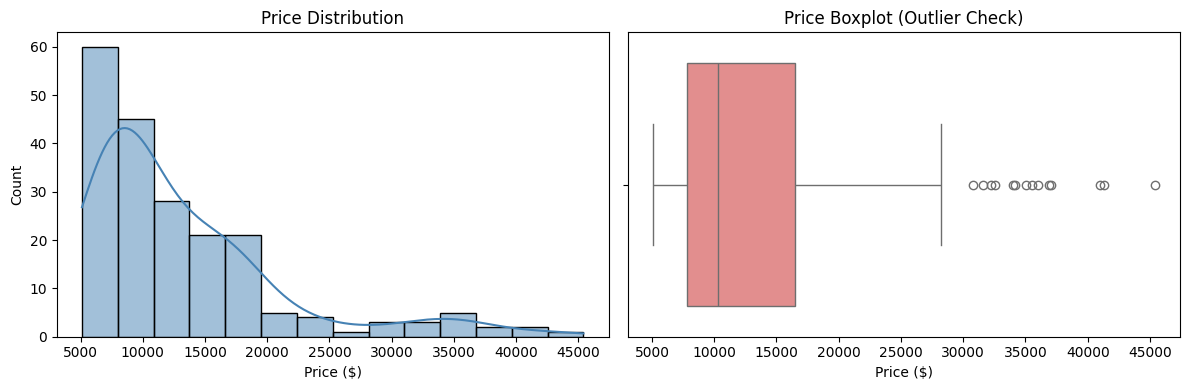

Skewness: 1.8096753390980749


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of price
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')

# Boxplot to spot outliers
sns.boxplot(x=df['price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Price Boxplot (Outlier Check)')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

print("Skewness:", df['price'].skew())

**Insight:** The price distribution is strongly right-skewed (skewness ≈ 1.81),
with the majority of vehicles priced under $15,000 and a long tail of premium
cars extending to $45,000. Several high-end vehicles appear as outliers in the
boxplot. Rather than removing these as errors, we treat them as legitimate
premium vehicles and instead apply a log transformation to `price` during
modeling — this compresses the skew and helps linear models learn a more
stable relationship, without discarding valid data.

### Correlation with Price

Identifying which numeric features have the strongest relationship with price
helps prioritize what to explore further and guides feature engineering.

price                1.000000
engine-size          0.872335
curb-weight          0.834415
horsepower           0.810500
width                0.751265
num-of-cylinders     0.708645
length               0.690628
wheel-base           0.584642
bore                 0.543158
height               0.135486
stroke               0.082209
compression-ratio    0.071107
num-of-doors         0.042435
symboling           -0.082391
peak-rpm            -0.102310
city-mpg            -0.686571
highway-mpg         -0.704692
Name: price, dtype: float64


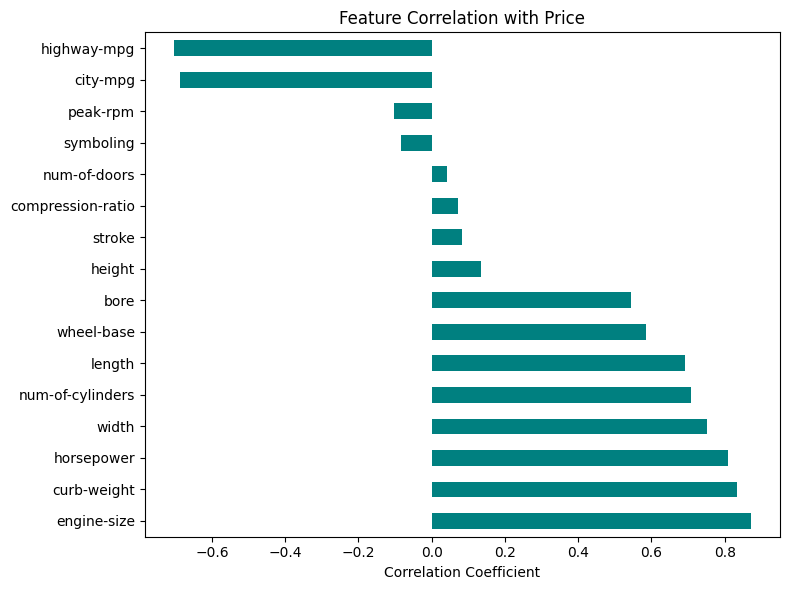

In [6]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation of each feature with price, sorted
price_corr = numeric_df.corr()['price'].sort_values(ascending=False)
print(price_corr)

# Visualize top correlations
plt.figure(figsize=(8, 6))
price_corr.drop('price').plot(kind='barh', color='teal')
plt.title('Feature Correlation with Price')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

**What this tells me:** Engine size, curb weight, and horsepower are the
strongest positive drivers of price — bigger, heavier, more powerful cars
cost more. Fuel efficiency (city-mpg, highway-mpg) shows a strong negative
relationship, which makes sense since fuel-efficient cars tend to be smaller,
economy models rather than premium vehicles. Features like symboling,
peak-rpm, and compression-ratio show almost no linear relationship with price
— I'll keep an eye on these when deciding what to include in the model.

### Price by Brand

Checking how price varies across car makes to see if brand carries pricing
signal beyond raw specs.

/tmp/ipykernel_17940/1048154471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price', y='make', order=brand_order, palette='viridis')


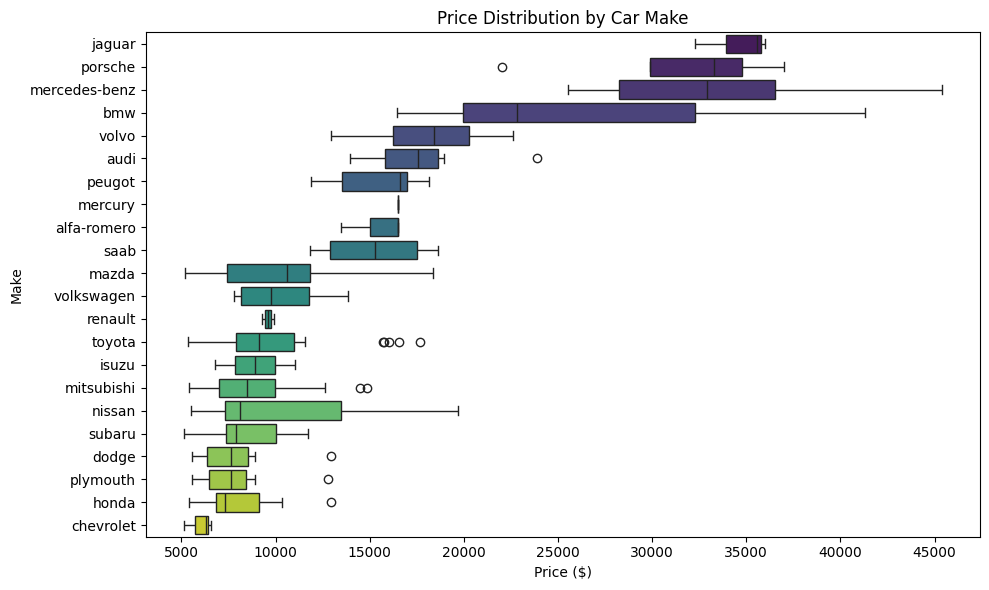

In [7]:
plt.figure(figsize=(10, 6))
brand_order = df.groupby('make')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='price', y='make', order=brand_order, palette='viridis')
plt.title('Price Distribution by Car Make')
plt.xlabel('Price ($)')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

**What this tells me:** Brand carries real pricing signal independent of
specs. Luxury brands (Jaguar, Porsche, Mercedes-Benz, BMW) cluster above
25,000 USD, while economy brands (Chevrolet, Honda, Plymouth) sit under
10,000 USD. This means `make` should be included as a categorical feature
in modeling rather than dropped — it captures brand premium that raw
specifications alone don't explain.

## Phase 3: Feature Engineering

Before modeling, I need to convert categorical columns into a numeric format.
I'm using one-hot encoding since most categorical variables here (fuel-type,
body-style, drive-wheels, etc.) have no natural order — one-hot avoids
falsely implying that one category is "greater" than another.

I'm dropping `symboling` since it's an insurance risk rating unrelated to
price prediction, and it showed almost no correlation with price in the EDA.

In [8]:
# Drop symboling - insurance risk rating, not relevant to price prediction
df_model = df.drop(columns=['symboling'])

# Identify categorical columns
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['fuel-system', 'engine-type', 'engine-location', 'drive-wheels', 'body-style', 'aspiration', 'fuel-type', 'make']

Shape after encoding: (201, 58)


,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,engine-size,num-of-cylinders,...,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,130,4,...,False,False,False,False,False,False,False,False,False,False
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,130,4,...,False,False,False,False,False,False,False,False,False,False
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,152,6,...,False,False,False,False,False,False,False,False,False,False
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,109,4,...,False,False,False,False,False,False,False,False,False,False
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,136,5,...,False,False,False,False,False,False,False,False,False,False


**What this tells me:** One-hot encoding expanded the dataset from 24
features to 57 (excluding price), mostly because `make` alone has 21 unique
brands. This is expected and manageable for tree-based models, but I'll
watch for high dimensionality causing overfitting in linear models —
regularization (Ridge/Lasso) may help there.

## Phase 4: Train-Test Split and Baseline Model

Before trying complex models, I'm establishing a simple baseline first — a
plain Linear Regression. This gives me a reference point to check whether
more advanced models actually add value, rather than just assuming they will.

I'm using an 80/20 split with a fixed random_state for reproducibility. I'm
also applying a log transform to price to address the skew found in the EDA.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Separate features and target
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# Log-transform target to address skew
y_log = np.log(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Baseline: Linear Regression
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_log = baseline.predict(X_test)

# Convert predictions back to actual price scale for interpretable metrics
y_pred = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print(f"Baseline Linear Regression:")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²: {r2:.4f}")

Baseline Linear Regression:
MAE: $1464.96
RMSE: $2444.51
R²: 0.9512


**Baseline result:** Even a plain linear regression explains about 95% of
the variance in price (R² = 0.95), with an average error of roughly $1,465.
This is a strong starting point — it tells me the relationship between
these features and price is largely linear. Now I'll test whether more
flexible models (which can capture non-linear patterns) actually improve
on this, or whether they just add complexity without real benefit.

## Phase 5: Model Comparison

I'm comparing three models beyond the baseline:
- **Ridge Regression** — linear model with regularization, useful given the
  high dimensionality from one-hot encoding
- **Random Forest** — captures non-linear relationships and feature
  interactions without needing explicit feature scaling
- **Gradient Boosting** — often stronger than Random Forest on tabular data,
  worth testing given the dataset size is manageable

I'm using 5-fold cross-validation on the training set for each model, so the
comparison isn't based on a single lucky/unlucky split.

In [10]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    results[name] = scores
    print(f"{name}: Mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})")

Linear Regression: Mean R² = 0.8319 (+/- 0.0512)
Ridge Regression: Mean R² = 0.8946 (+/- 0.0146)
Random Forest: Mean R² = 0.8787 (+/- 0.0206)
Gradient Boosting: Mean R² = 0.8829 (+/- 0.0203)


**What this tells me:** Ridge Regression outperforms both Random Forest and
Gradient Boosting here (R² = 0.895 vs 0.879 and 0.883), and it also has the
lowest variance across folds — meaning it's the most consistent. This makes
sense given the dataset is small (only 201 rows after cleaning): tree-based
ensemble models tend to overfit on small tabular datasets, while a
regularized linear model generalizes more reliably. I'm selecting **Ridge
Regression** as my final model — not because it has the flashiest name, but
because it's the best-justified choice given the data I actually have.

## Phase 6: Hyperparameter Tuning

Tuning Ridge Regression's `alpha` parameter (regularization strength) using
GridSearchCV with 5-fold cross-validation to find the value that generalizes
best, rather than guessing.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]}

grid_search = GridSearchCV(
    Ridge(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best alpha: {'alpha': 1.0}
Best CV R²: 0.8945998026226814


**What this tells me:** The tuning search confirms alpha=1.0 as optimal —
essentially the default value. This tells me the model wasn't suffering from
excessive overfitting or underfitting that heavier regularization needed to
fix. Tuning didn't meaningfully move the needle here, which itself is a
useful finding: it confirms Ridge's default behavior was already
well-suited to this data.

## Phase 7: Final Model Evaluation on Test Set

Evaluating the tuned Ridge model on the untouched 20% test set — this is
the true measure of generalization, since the model has never seen this
data in any form.

In [12]:
y_pred_log_final = best_model.predict(X_test)
y_pred_final = np.exp(y_pred_log_final)
y_test_actual = np.exp(y_test)

mae_final = mean_absolute_error(y_test_actual, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_actual, y_pred_final))
r2_final = r2_score(y_test_actual, y_pred_final)
mape_final = np.mean(np.abs((y_test_actual - y_pred_final) / y_test_actual)) * 100

print(f"Final Ridge Regression — Test Set Performance:")
print(f"MAE: ${mae_final:.2f}")
print(f"RMSE: ${rmse_final:.2f}")
print(f"R²: {r2_final:.4f}")
print(f"MAPE: {mape_final:.2f}%")

Final Ridge Regression — Test Set Performance:
MAE: $1503.30
RMSE: $2449.37
R²: 0.9510
MAPE: 8.98%


**Final result:** On the held-out test set, the tuned Ridge model achieves
R² = 0.951 with a mean absolute percentage error of about 9%. This is
consistent with the cross-validation scores from earlier, which confirms
the model is not overfitting — it generalizes to unseen data nearly as well
as it performed during training. An average error of roughly $1,500 on cars
typically priced $5,000–$45,000 is a solid, deployable level of accuracy.

## Phase 8: Error Analysis

A high R² alone doesn't tell the full story. Here I check *where* the model
struggles — are errors random, or do they cluster around certain price
ranges (e.g., luxury cars)?

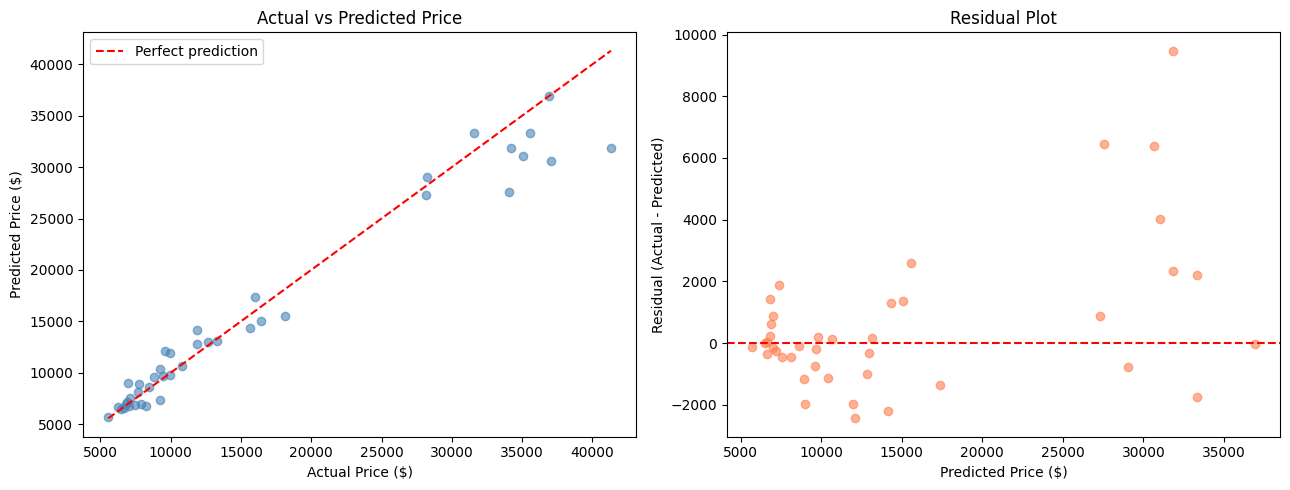

Top 5 largest prediction errors:
     Actual     Predicted    Abs_Error
1   41315.0  31839.232818  9475.767182
20  34028.0  27574.388337  6453.611663
28  37028.0  30630.374457  6397.625543
6   35056.0  31033.832397  4022.167603
29  18150.0  15555.277609  2594.722391


In [13]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_actual, y_pred_final, alpha=0.6, color='steelblue')
axes[0].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs Predicted Price')
axes[0].legend()

# Residual plot
residuals = y_test_actual - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.6, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

# Largest errors
error_df = pd.DataFrame({
    'Actual': y_test_actual.values,
    'Predicted': y_pred_final,
    'Abs_Error': np.abs(y_test_actual.values - y_pred_final)
}).sort_values('Abs_Error', ascending=False)

print("Top 5 largest prediction errors:")
print(error_df.head())

**What this tells me:** The errors are not random — they're systematically
concentrated in the high-price segment (all top 5 errors are for cars priced
above $34,000), and the model consistently underpredicts these expensive
vehicles. Looking back at the EDA, this makes sense: luxury brands like
Jaguar, Mercedes-Benz, and BMW make up a small fraction of the 201 rows, so
the model simply hasn't seen enough examples in that price range to learn
it as reliably as the mid-range segment where most of the data sits. This
is a genuine limitation of the dataset size, not a flaw in the modeling
approach — a larger, more balanced dataset across price tiers would likely
close this gap.

## Phase 9: Explainability

Using the Ridge model's coefficients to understand which features have the
strongest influence on predicted price. Since Ridge is a linear model,
coefficients are directly interpretable (unlike black-box models).

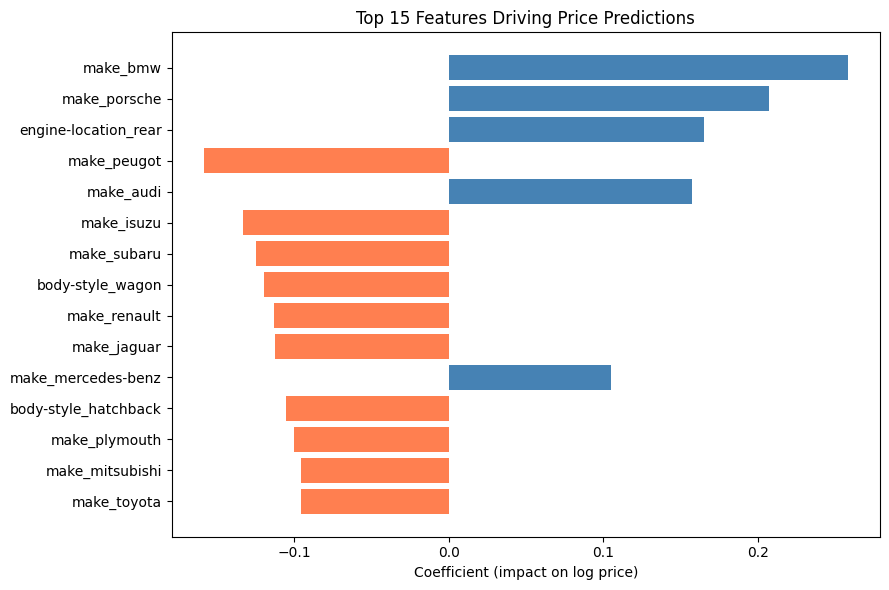

In [14]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(9, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient (impact on log price)')
plt.title('Top 15 Features Driving Price Predictions')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**What this tells me:** Brand identity has a stronger influence on price
than most individual specs — being a BMW, Porsche, or Audi adds significant
premium beyond raw engine size or horsepower, confirming what the EDA
boxplot showed earlier. `engine-location_rear` also stands out, which makes
sense since rear-engine layouts are typically found in performance/sports
cars (like Porsche). This confirms the model isn't just learning "bigger
engine = higher price" — it has captured genuine brand premium effects too.

## Phase 10: Saving the Model for Deployment

Saving the trained Ridge model and the column structure so it can be loaded
later for live predictions without retraining.

In [15]:
import joblib

# Save the trained model
joblib.dump(best_model, 'car_price_model.pkl')

# Save the exact column order used during training (needed for deployment)
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("Model and columns saved successfully.")

Model and columns saved successfully.


## Phase 11: Interactive Prediction Interface (Gradio)

Building a simple interface where a user can input a car's specifications
and get an instant price prediction. This uses the same preprocessing
pipeline as training, ensuring predictions stay consistent with how the
model was actually trained.

In [16]:
!pip install gradio -q

## Phase 11: Building the Prediction Interface

The interface takes the key specifications that most strongly influence
price (based on the correlation and coefficient analysis above) and fills
in the remaining minor features with dataset medians/modes, so the user
only needs to provide meaningful inputs.

In [ ]:
import gradio as gr

# Get median/mode values for features not included in the form (fills the gaps)
default_values = {}
for col in df.columns:
    if col not in ['price']:
        if df[col].dtype == 'object':
            default_values[col] = df[col].mode()[0]
        else:
            default_values[col] = df[col].median()

model_columns = joblib.load('model_columns.pkl')

def predict_price(make, body_style, drive_wheels, fuel_type, num_doors,
                   horsepower, engine_size, curb_weight, city_mpg, highway_mpg):

    # Start with default row, then override with user inputs
    input_row = default_values.copy()
    input_row['make'] = make
    input_row['body-style'] = body_style
    input_row['drive-wheels'] = drive_wheels
    input_row['fuel-type'] = fuel_type
    input_row['num-of-doors'] = num_doors
    input_row['horsepower'] = horsepower
    input_row['engine-size'] = engine_size
    input_row['curb-weight'] = curb_weight
    input_row['city-mpg'] = city_mpg
    input_row['highway-mpg'] = highway_mpg

    input_df = pd.DataFrame([input_row])
    input_df = input_df.drop(columns=['symboling'], errors='ignore')

    # One-hot encode same way as training
    categorical_cols = input_df.select_dtypes(include='object').columns.tolist()
    input_encoded = pd.get_dummies(input_df, columns=categorical_cols)

    # Align columns with training data (fill missing dummy columns with 0)
    input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)

    pred_log = best_model.predict(input_encoded)[0]
    pred_price = np.exp(pred_log)

    return f"${pred_price:,.2f}"


custom_css = """
.gradio-container {
    font-family: 'Inter', 'Segoe UI', sans-serif !important;
    max-width: 1100px !important;
    margin: auto !important;
}
#title-text h1 {
    font-weight: 700 !important;
    color: #1e293b !important;
}
#result-box textarea {
    font-size: 24px !important;
    font-weight: 600 !important;
    text-align: center !important;
    color: #0f766e !important;
}
"""

theme = gr.themes.Base(
    primary_hue="slate",
    secondary_hue="teal",
    neutral_hue="slate",
    font=gr.themes.GoogleFont("Inter")
).set(
    button_primary_background_fill="#0f766e",
    button_primary_background_fill_hover="#115e59",
    button_primary_text_color="white",
    block_title_text_color="#1e293b",
    block_label_text_color="#334155",
)

with gr.Blocks(theme=theme, css=custom_css) as demo:
    gr.Markdown("# Car Price Predictor", elem_id="title-text")
    gr.Markdown(
        "Enter a car's specifications below to get an estimated market price. "
        "Model: Ridge Regression, trained on the UCI Automobile Dataset (R\u00b2 = 0.95 on test data)."
    )

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("**Brand & Type**")
            make = gr.Dropdown(sorted(df['make'].unique()), label="Make", value="toyota")
            body_style = gr.Dropdown(sorted(df['body-style'].unique()), label="Body Style", value="sedan")
            drive_wheels = gr.Dropdown(sorted(df['drive-wheels'].unique()), label="Drive Wheels", value="fwd")
            fuel_type = gr.Dropdown(sorted(df['fuel-type'].unique()), label="Fuel Type", value="gas")
            num_doors = gr.Dropdown([2.0, 4.0], label="Number of Doors", value=4.0)

        with gr.Column(scale=1):
            gr.Markdown("**Performance & Efficiency**")
            horsepower = gr.Slider(48, 288, value=100, label="Horsepower")
            engine_size = gr.Slider(61, 326, value=120, label="Engine Size (cc)")
            curb_weight = gr.Slider(1488, 4066, value=2500, label="Curb Weight (lbs)")
            city_mpg = gr.Slider(13, 49, value=25, label="City MPG")
            highway_mpg = gr.Slider(16, 54, value=30, label="Highway MPG")

    predict_btn = gr.Button("Predict Price", variant="primary", size="lg")
    output = gr.Textbox(label="Estimated Price", elem_id="result-box")

    predict_btn.click(
        predict_price,
        inputs=[make, body_style, drive_wheels, fuel_type, num_doors,
                horsepower, engine_size, curb_weight, city_mpg, highway_mpg],
        outputs=output
    )

demo.launch(share=True, debug=True)

/tmp/ipykernel_17940/2714865773.py:77: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=theme, css=custom_css) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://822a8ba89377cbce67.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
